In [1]:
import os
os.chdir('../')

In [2]:
import pandas as pd
data = pd.read_csv('Datasets/video_game_reviews.csv').set_index('id')
data.head()

,review,review_rating
id,,
1,1st shipment received a book instead of the ga...,1
2,I still haven't figured this one out. Did ever...,2
3,I bought this and the key didn't work. It was...,1
4,I love it! Use it all the time. Really works p...,5
5,my grandkids (and their parents) love playing ...,5


In [4]:
from sklearn.model_selection import train_test_split
X=data.review
y=data.review_rating
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=1031)
print(X_train.head())
print(y_train.head())

id
2601     This game got boring within 20 minutes of play...
11604    It is a great game, but the plot is just so la...
3105     In 2002, the Sting Entertainment-developed Yak...
5270     I love the Mortimer Beckett puzzles but let me...
21767    Coming from the bitter taste of disappointment...
Name: review, dtype: str
id
2601     1
11604    4
3105     4
5270     3
21767    4
Name: review_rating, dtype: int64


In [5]:
X_train.shape,X_test.shape,data.shape

((18656,), (7996,), (26652, 2))

In [6]:
y_train.shape,y_test.shape,data.shape

((18656,), (7996,), (26652, 2))

In [12]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

tf_vectorizer = CountVectorizer(lowercase = True, stop_words = 'english',ngram_range=(1,1))
tf_vectorizer.fit(X_train)
X_train_tf = tf_vectorizer.transform(X_train)
X_test_tf = tf_vectorizer.transform(X_test)

In [13]:
X_train_tf

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 802906 stored elements and shape (18656, 36338)>

In [15]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
tree = DecisionTreeRegressor()
tree.fit(X_train_tf, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

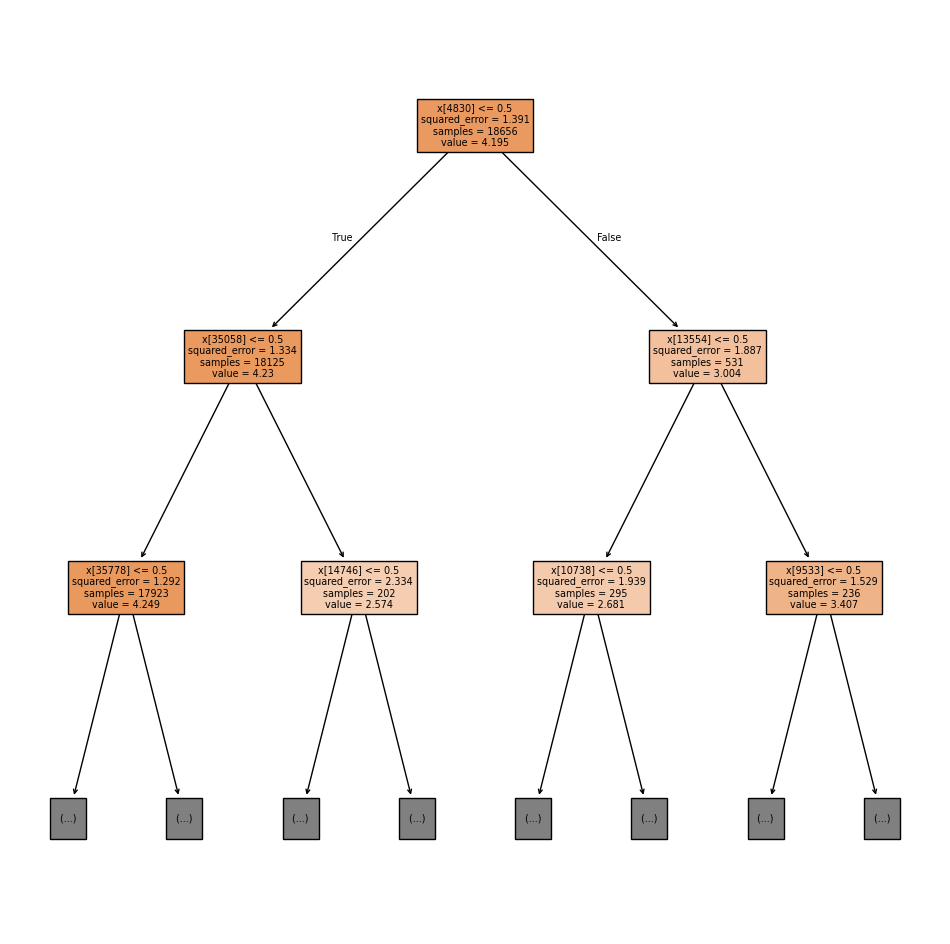

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize = (12,12))
plot_tree(tree,max_depth=2,filled=True,)
plt.show()

In [17]:
tf_vectorizer.get_feature_names_out()[4830]

'boring'

In [18]:
X_train_tf.shape

(18656, 36338)

In [19]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X_train_tf, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
coefficients = pd.DataFrame(lm.coef_, columns=['coefficients'])
coefficients.index = tf_vectorizer.get_feature_names_out()
coefficients.abs().sort_values(['coefficients'],ascending = False)

,coefficients
fluctuate,28.937711
unaware,28.228320
scanner,27.320210
inventively,27.091308
confession,25.646275
...,...
gyroscopic,0.000401
brought,0.000312
ejects,0.000294
flag,0.000218


In [21]:
from sklearn.metrics import root_mean_squared_error
pred = tree.predict(X_test_tf)
root_mean_squared_error(y_test, pred)

1.3679509676632247

In [22]:
from sklearn.metrics import root_mean_squared_error
pred = lm.predict(X_test_tf)
root_mean_squared_error(y_test, pred)

13.564573062911995